In [5]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
# load dataset
data = pd.read_excel("C:\\Users\\D.Sagar\\OneDrive\\Desktop\\Innomatics_Folder\\Projects\\Real_Estate_Rent_Dataframe_2.xlsx")

In [7]:
data

,index,Name,Type of Appartment(BHK),Measurements,Price,Deposit,Area,City,Price/sqft
0,0,3C Lotus Panache,2,"1,220 sqft","₹27,000","₹54,000",Sector,"110, Noida",22.13
1,1,Antriksh Nature,3,"1,695 sqft","₹40,000","₹4,000",Sector,"52, Noida",23.60
2,2,Amrapali HeartBeat City,3,"1,735 sqft","₹52,000",2 months rent,Sector,"107, Noida",29.97
3,3,Panchsheel Pratishtha,3,"2,050 sqft","₹42,500",2 months rent,Sector,"75, Noida",20.73
4,4,Kalpataru Vista,3,"3,000 sqft",₹1.1 Lac,2 months rent,Sector,"128, Noida",0.00
...,...,...,...,...,...,...,...,...,...
1808,1531,"Udhyognagar, Rajkot",2,799 sqft,"₹18,000",NaN,Udhyognagar,Rajkot,22.53
1809,1532,"Udhyognagar, Rajkot",2,800 sqft,"₹18,000",NaN,Udhyognagar,Rajkot,22.50
1810,1533,"Gopal Nagar, Rajkot",3,720 sqft,"₹11,500",NaN,Gopal,"Nagar, Rajkot",15.97
1811,1534,Rail nagar,3,657 sqft,"₹15,000",NaN,Radhika,"residency 2, Rajkot",22.83


In [8]:

data.shape

(1813, 9)

In [9]:
data.columns

Index(['index', 'Name', 'Type of Appartment(BHK)', 'Measurements', 'Price',
       'Deposit', 'Area', 'City', 'Price/sqft'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    1813 non-null   int64  
 1   Name                     1809 non-null   object 
 2   Type of Appartment(BHK)  1813 non-null   object 
 3   Measurements             1813 non-null   object 
 4   Price                    1813 non-null   object 
 5   Deposit                  1310 non-null   object 
 6   Area                     1813 non-null   object 
 7   City                     1801 non-null   object 
 8   Price/sqft               1813 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 127.6+ KB


In [11]:
# Standardize Column Names
data.columns = data.columns.str.lower().str.replace(' ', '_')

In [12]:
data.columns

Index(['index', 'name', 'type_of_appartment(bhk)', 'measurements', 'price',
       'deposit', 'area', 'city', 'price/sqft'],
      dtype='object')

In [13]:
# Check Missing Values
data.isnull().sum()

index                        0
name                         4
type_of_appartment(bhk)      0
measurements                 0
price                        0
deposit                    503
area                         0
city                        12
price/sqft                   0
dtype: int64

In [14]:
Drop Unnecessary Column
if 'index' in data.columns:
    data = data.drop(columns=['index'])

In [15]:
data

,name,type_of_appartment(bhk),measurements,price,deposit,area,city,price/sqft
0,3C Lotus Panache,2,"1,220 sqft","₹27,000","₹54,000",Sector,"110, Noida",22.13
1,Antriksh Nature,3,"1,695 sqft","₹40,000","₹4,000",Sector,"52, Noida",23.60
2,Amrapali HeartBeat City,3,"1,735 sqft","₹52,000",2 months rent,Sector,"107, Noida",29.97
3,Panchsheel Pratishtha,3,"2,050 sqft","₹42,500",2 months rent,Sector,"75, Noida",20.73
4,Kalpataru Vista,3,"3,000 sqft",₹1.1 Lac,2 months rent,Sector,"128, Noida",0.00
...,...,...,...,...,...,...,...,...
1808,"Udhyognagar, Rajkot",2,799 sqft,"₹18,000",NaN,Udhyognagar,Rajkot,22.53
1809,"Udhyognagar, Rajkot",2,800 sqft,"₹18,000",NaN,Udhyognagar,Rajkot,22.50
1810,"Gopal Nagar, Rajkot",3,720 sqft,"₹11,500",NaN,Gopal,"Nagar, Rajkot",15.97
1811,Rail nagar,3,657 sqft,"₹15,000",NaN,Radhika,"residency 2, Rajkot",22.83


In [16]:
# Remove Old Price/sqft Column
data = data.drop(columns=['price/sqft'])

In [17]:
data

,name,type_of_appartment(bhk),measurements,price,deposit,area,city
0,3C Lotus Panache,2,"1,220 sqft","₹27,000","₹54,000",Sector,"110, Noida"
1,Antriksh Nature,3,"1,695 sqft","₹40,000","₹4,000",Sector,"52, Noida"
2,Amrapali HeartBeat City,3,"1,735 sqft","₹52,000",2 months rent,Sector,"107, Noida"
3,Panchsheel Pratishtha,3,"2,050 sqft","₹42,500",2 months rent,Sector,"75, Noida"
4,Kalpataru Vista,3,"3,000 sqft",₹1.1 Lac,2 months rent,Sector,"128, Noida"
...,...,...,...,...,...,...,...
1808,"Udhyognagar, Rajkot",2,799 sqft,"₹18,000",NaN,Udhyognagar,Rajkot
1809,"Udhyognagar, Rajkot",2,800 sqft,"₹18,000",NaN,Udhyognagar,Rajkot
1810,"Gopal Nagar, Rajkot",3,720 sqft,"₹11,500",NaN,Gopal,"Nagar, Rajkot"
1811,Rail nagar,3,657 sqft,"₹15,000",NaN,Radhika,"residency 2, Rajkot"


In [18]:
# Remove ₹ symbol and commas 
data['price'] = data['price'].astype(str).str.replace('₹','').str.replace(',','')

In [19]:
data['price']

0         27000
1         40000
2         52000
3         42500
4       1.1 Lac
         ...   
1808      18000
1809      18000
1810      11500
1811      15000
1812      18000
Name: price, Length: 1813, dtype: object

In [20]:
# Convert Crores to Lakhs
data['price'] = data['price'].astype(str).str.replace('₹','').str.replace(',','').str.replace(' Lac','').str.replace(' Cr','')

In [21]:
data['price']

0       27000
1       40000
2       52000
3       42500
4         1.1
        ...  
1808    18000
1809    18000
1810    11500
1811    15000
1812    18000
Name: price, Length: 1813, dtype: object

In [22]:
# Convert Price Column to Numeric
data['price'] = pd.to_numeric(data['price'])

In [23]:
data['price']

0       27000.0
1       40000.0
2       52000.0
3       42500.0
4           1.1
         ...   
1808    18000.0
1809    18000.0
1810    11500.0
1811    15000.0
1812    18000.0
Name: price, Length: 1813, dtype: float64

In [24]:
data['measurements'] = data['measurements'].astype(str).str.replace(',', '').str.replace(' sqft','').astype(float)

In [25]:
data['measurements']

0       1220.0
1       1695.0
2       1735.0
3       2050.0
4       3000.0
         ...  
1808     799.0
1809     800.0
1810     720.0
1811     657.0
1812    1025.0
Name: measurements, Length: 1813, dtype: float64

In [26]:
# handling missing values
data = data.dropna(subset=['name','city'])

In [27]:
data

,name,type_of_appartment(bhk),measurements,price,deposit,area,city
0,3C Lotus Panache,2,1220.0,27000.0,"₹54,000",Sector,"110, Noida"
1,Antriksh Nature,3,1695.0,40000.0,"₹4,000",Sector,"52, Noida"
2,Amrapali HeartBeat City,3,1735.0,52000.0,2 months rent,Sector,"107, Noida"
3,Panchsheel Pratishtha,3,2050.0,42500.0,2 months rent,Sector,"75, Noida"
4,Kalpataru Vista,3,3000.0,1.1,2 months rent,Sector,"128, Noida"
...,...,...,...,...,...,...,...
1807,"Dharam Nagar, Rajkot",1,250.0,5500.0,NaN,Dharam,"Nagar, Rajkot"
1808,"Udhyognagar, Rajkot",2,799.0,18000.0,NaN,Udhyognagar,Rajkot
1809,"Udhyognagar, Rajkot",2,800.0,18000.0,NaN,Udhyognagar,Rajkot
1810,"Gopal Nagar, Rajkot",3,720.0,11500.0,NaN,Gopal,"Nagar, Rajkot"


In [28]:
data['deposit'] = data['deposit'].fillna(0)

In [29]:
data['deposit']

0             ₹54,000
1              ₹4,000
2       2 months rent
3       2 months rent
4       2 months rent
            ...      
1807                0
1808                0
1809                0
1810                0
1811                0
Name: deposit, Length: 1797, dtype: object

In [30]:
# remove duplicate rows
data = data.drop_duplicates()

In [31]:
data

,name,type_of_appartment(bhk),measurements,price,deposit,area,city
0,3C Lotus Panache,2,1220.0,27000.0,"₹54,000",Sector,"110, Noida"
1,Antriksh Nature,3,1695.0,40000.0,"₹4,000",Sector,"52, Noida"
2,Amrapali HeartBeat City,3,1735.0,52000.0,2 months rent,Sector,"107, Noida"
3,Panchsheel Pratishtha,3,2050.0,42500.0,2 months rent,Sector,"75, Noida"
4,Kalpataru Vista,3,3000.0,1.1,2 months rent,Sector,"128, Noida"
...,...,...,...,...,...,...,...
1777,"Magadh Colony, Gaya",2,1500.0,10000.0,1 months rent,Magadh,"Colony, Gaya"
1778,"AP Colony, Gaya",1,350.0,4000.0,"₹4,000",AP,"Colony, Gaya"
1779,"AP Colony, Gaya",1,650.0,6000.0,0,AP,"Colony, Gaya"
1784,Ashar Axis,2,980.0,43000.0,"₹1,75,000",Majiwada,Thane


In [32]:
data['measurements'] = pd.to_numeric(data['measurements'])

In [33]:
# Create Price per Sqft Column
data['price_per_sqft'] = data['price'] / data['measurements']

In [34]:
data['price_per_sqft']

0       22.131148
1       23.598820
2       29.971182
3       20.731707
4        0.000367
          ...    
1777     6.666667
1778    11.428571
1779     9.230769
1784    43.877551
1804    17.142857
Name: price_per_sqft, Length: 1652, dtype: float64

In [35]:
data

,name,type_of_appartment(bhk),measurements,price,deposit,area,city,price_per_sqft
0,3C Lotus Panache,2,1220.0,27000.0,"₹54,000",Sector,"110, Noida",22.131148
1,Antriksh Nature,3,1695.0,40000.0,"₹4,000",Sector,"52, Noida",23.598820
2,Amrapali HeartBeat City,3,1735.0,52000.0,2 months rent,Sector,"107, Noida",29.971182
3,Panchsheel Pratishtha,3,2050.0,42500.0,2 months rent,Sector,"75, Noida",20.731707
4,Kalpataru Vista,3,3000.0,1.1,2 months rent,Sector,"128, Noida",0.000367
...,...,...,...,...,...,...,...,...
1777,"Magadh Colony, Gaya",2,1500.0,10000.0,1 months rent,Magadh,"Colony, Gaya",6.666667
1778,"AP Colony, Gaya",1,350.0,4000.0,"₹4,000",AP,"Colony, Gaya",11.428571
1779,"AP Colony, Gaya",1,650.0,6000.0,0,AP,"Colony, Gaya",9.230769
1784,Ashar Axis,2,980.0,43000.0,"₹1,75,000",Majiwada,Thane,43.877551


In [36]:
data.head()

,name,type_of_appartment(bhk),measurements,price,deposit,area,city,price_per_sqft
0,3C Lotus Panache,2,1220.0,27000.0,"₹54,000",Sector,"110, Noida",22.131148
1,Antriksh Nature,3,1695.0,40000.0,"₹4,000",Sector,"52, Noida",23.598820
2,Amrapali HeartBeat City,3,1735.0,52000.0,2 months rent,Sector,"107, Noida",29.971182
3,Panchsheel Pratishtha,3,2050.0,42500.0,2 months rent,Sector,"75, Noida",20.731707
4,Kalpataru Vista,3,3000.0,1.1,2 months rent,Sector,"128, Noida",0.000367


In [37]:
data.describe()

,measurements,price,price_per_sqft
count,1.652000e+03,1652.000000,1652.000000
mean,1.301524e+06,23069.027034,39.378507
std,5.283534e+07,18734.575465,461.522756
min,1.000000e+00,1.000000,0.000002
25%,8.300000e+02,10000.000000,10.000000
50%,1.200000e+03,18000.000000,16.666667
75%,1.600000e+03,30000.000000,26.666667
max,2.147484e+09,98000.000000,16250.000000


# Analysis

In [38]:
data['city'].value_counts()

city
Pune           56
Vijayawada     54
Guntur         52
Ranchi         50
Kanchipuram    47
               ..
Extension       1
46, Noida       1
74, Noida       1
93 B, Noida     1
43, Noida       1
Name: count, Length: 448, dtype: int64

In [39]:
data['type_of_appartment(bhk)'].value_counts()

type_of_appartment(bhk)
2         661
3         587
1         237
4         139
Studio     28
Name: count, dtype: int64

In [40]:
data['area'].value_counts()

area
Sector            96
Hiranandani       29
Bodhgaya          20
Besa              15
Nipania           14
                  ..
Sholinganallur     1
Medavakkam         1
Thoraipakkam       1
Khode              1
Chandshi           1
Name: count, Length: 764, dtype: int64

In [41]:
data['price'].mean()

np.float64(23069.027033898303)

In [42]:
data['measurements'].max()

2147483647.0

In [43]:
data['measurements'].min()

1.0

In [44]:
data['price_per_sqft'].mean()

np.float64(39.378507079787525)

In [45]:
data.loc[data['price'].idxmax()]

name                       Lake Primrose
type_of_appartment(bhk)                3
measurements                       850.0
price                            98000.0
deposit                        ₹3,00,000
area                               Powai
city                              Mumbai
price_per_sqft                115.294118
Name: 249, dtype: object

In [46]:
data.loc[data['price'].idxmin()]

name                               Ocean Pearl Apartments
type_of_appartment(bhk)                                 3
measurements                                       1750.0
price                                                 1.0
deposit                                         ₹5,00,000
area                                                Nanja
city                       Reddy Colony, Old Airport Road
price_per_sqft                                   0.000571
Name: 51, dtype: object

In [50]:
data.reset_index

<bound method DataFrame.reset_index of                          name type_of_appartment(bhk)  measurements    price  \
0            3C Lotus Panache                       2          1220  27000.0   
1             Antriksh Nature                       3          1695  40000.0   
2     Amrapali HeartBeat City                       3          1735  52000.0   
3       Panchsheel Pratishtha                       3          2050  42500.0   
4             Kalpataru Vista                       3          3000      1.1   
...                       ...                     ...           ...      ...   
1647      Magadh Colony, Gaya                       2          1500  10000.0   
1648          AP Colony, Gaya                       1           350   4000.0   
1649          AP Colony, Gaya                       1           650   6000.0   
1650               Ashar Axis                       2           980  43000.0   
1651        Pride Laxmi Ramna                       2           700  12000.0   



In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     1652 non-null   object 
 1   type_of_appartment(bhk)  1652 non-null   object 
 2   measurements             1652 non-null   int64  
 3   price                    1652 non-null   float64
 4   deposit                  1652 non-null   object 
 5   area                     1652 non-null   object 
 6   city                     1652 non-null   object 
 7   price_per_sqft           1652 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 103.4+ KB


In [48]:
data.to_excel("Cleaned_Rent_data.xlsx",index=False)

In [49]:
data=pd.read_excel("./Cleaned_Rent_data.xlsx")

# Visualization

### Top 10 Most Listed Rental Properties

C:\Users\D.Sagar\AppData\Local\Temp\ipykernel_16168\1133272479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_names.index, y=top_names.values, palette="deep")


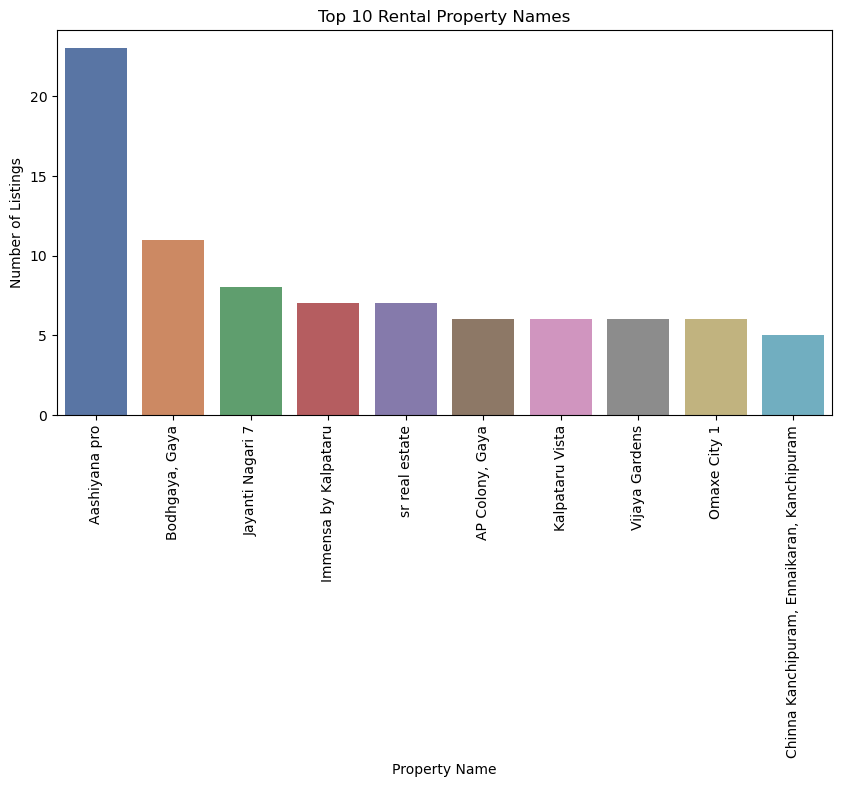

In [57]:
# Bar Graph
top_names = data["name"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_names.index, y=top_names.values, palette="deep")

plt.xticks(rotation=90)
plt.title("Top 10 Rental Property Names")
plt.xlabel("Property Name")
plt.ylabel("Number of Listings")

plt.show()


- This chart shows the property names that appear most frequently in the rental listings dataset.
- A higher count indicates projects or buildings that have more rental availability.

### Distribution of Rental Properties by BHK Type

C:\Users\D.Sagar\AppData\Local\Temp\ipykernel_16168\3275483697.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="type_of_appartment(bhk)", data=data, palette="pastel")


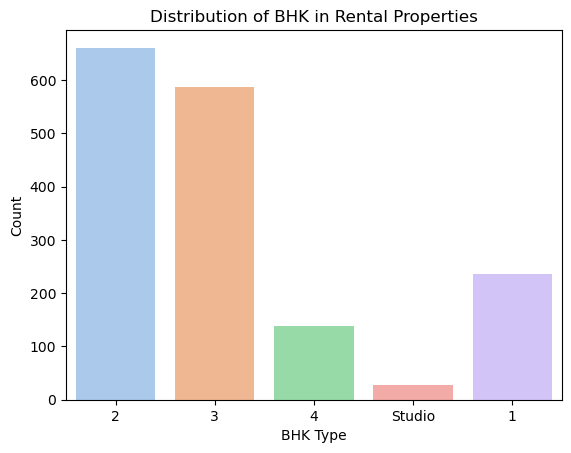

In [58]:
sns.countplot(x="type_of_appartment(bhk)", data=data, palette="pastel")

plt.title("Distribution of BHK in Rental Properties")

plt.xlabel("BHK Type")
plt.ylabel("Count")

plt.show()

- The plot shows how rental listings are distributed across different BHK apartment types.
- It helps identify which apartment configurations are most commonly available for rent.

### This graph shows the number of rental property listings available in each city.It helps identify which cities have the highest rental market activity.

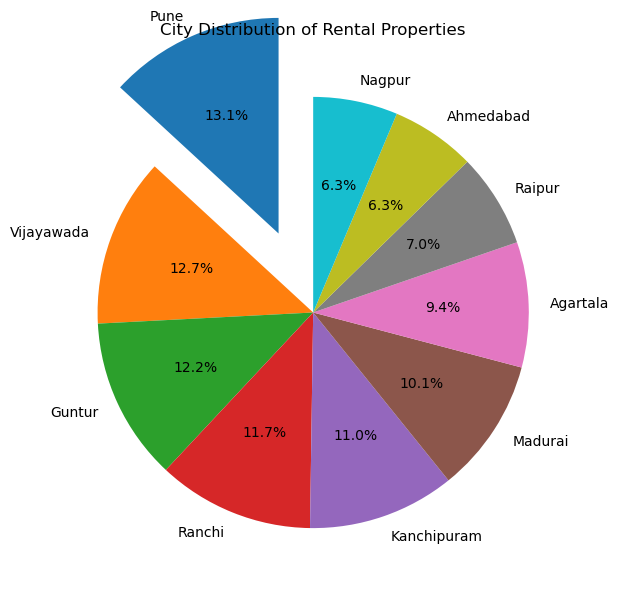

In [59]:
# Pie Chart — Apartment Type Distribution (BHK)
plt.figure(figsize=(7,7))

data["city"].value_counts().head(10).plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.4,0,0,0,0,0,0,0,0,0]
)

plt.title("City Distribution of Rental Properties")

plt.ylabel("")

plt.show()

- The pie chart illustrates the proportion of rental listings across major cities.
- Cities with larger slices indicate higher rental property availability.

### Top 10 Areas with Highest Rental Property Availability

C:\Users\D.Sagar\AppData\Local\Temp\ipykernel_16168\3911130093.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_areas.index, y=top_areas.values, palette="muted")


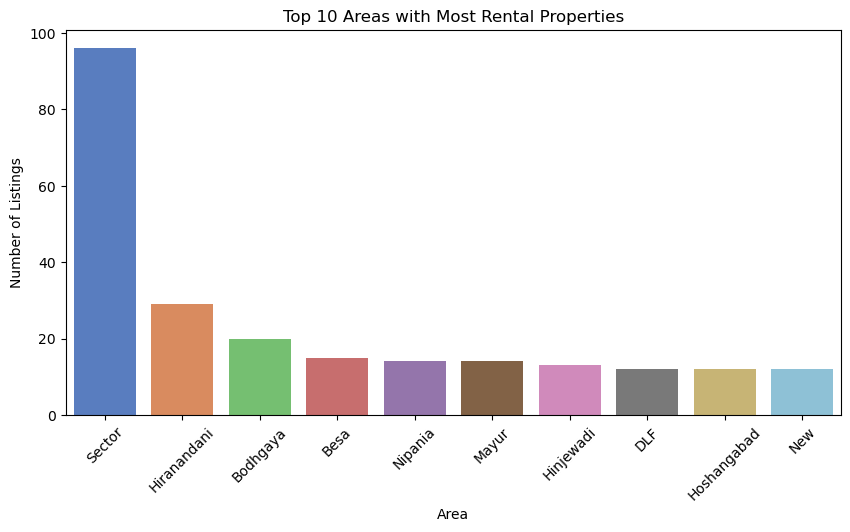

In [90]:
# Histogram — Price Distribution
top_areas = data["area"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_areas.index, y=top_areas.values, palette="muted")

plt.title("Top 10 Areas with Most Rental Properties")

plt.xlabel("Area")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)

plt.show()

- This visualization highlights the areas that have the most rental property listings.
- These areas are likely to be popular residential locations with high housing demand

### Top Cities Offering Rental Properties Within 40k

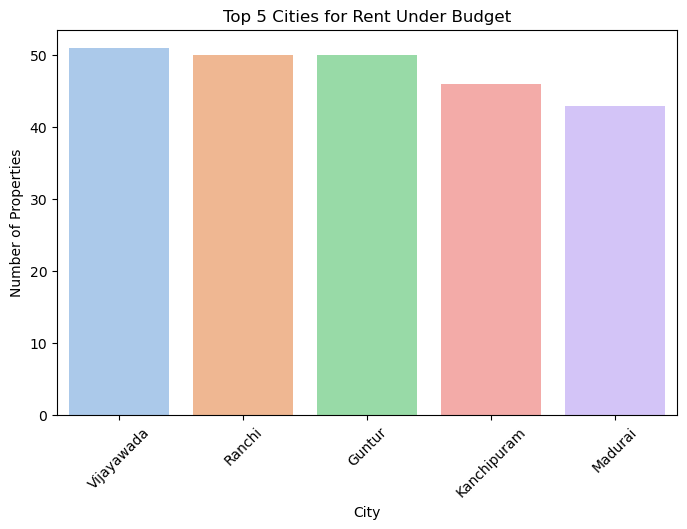

In [3]:
budget_df = data[data["price"] <= 40000]

top5_cities = budget_df["city"].value_counts().head(5)

plt.figure(figsize=(8,5))

sns.barplot(x=top5_cities.index, y=top5_cities.values, palette="pastel")

plt.title("Top 5 Cities for Rent Under Budget")

plt.xlabel("City")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45)

plt.show()

- This chart shows cities that provide the highest number of rental properties within a defined budget range.
- It helps identify affordable cities for tenants with limited budgets

In [67]:
data.columns

Index(['name', 'type_of_appartment(bhk)', 'measurements', 'price', 'deposit',
       'area', 'city', 'price_per_sqft'],
      dtype='object')

### City-wise Comparison of Rental Price per Square Foot

C:\Users\D.Sagar\AppData\Local\Temp\ipykernel_16168\1127431761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_city.index, y=top_city.values, palette="viridis")


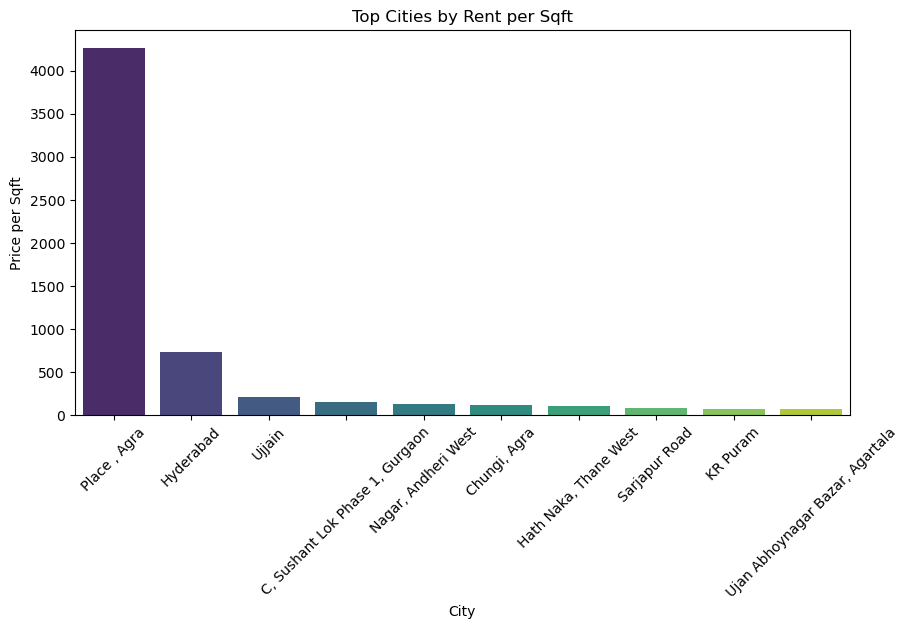

In [72]:
top_city = data.groupby("city")["price_per_sqft"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_city.index, y=top_city.values, palette="viridis")

plt.title("Top Cities by Rent per Sqft")

plt.xlabel("City")
plt.ylabel("Price per Sqft")

plt.xticks(rotation=45)

plt.show()

- This visualization compares rental cost relative to property size across cities.
- Cities with higher values indicate more expensive rental markets.

### Affordable Rental Areas in Hyderabad

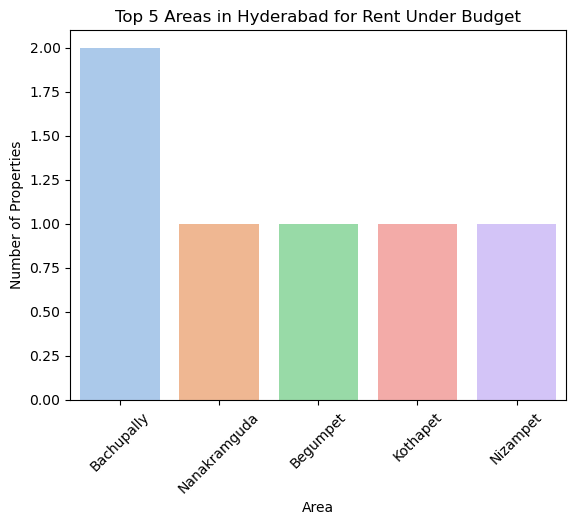

In [4]:
budget = 40000

hyd_df = data[(data["city"]=="Hyderabad") & (data["price"]<=budget)]

top5 = hyd_df["area"].value_counts().head(5)

sns.barplot(x=top5.index, y=top5.values, palette='pastel')

plt.title("Top 5 Areas in Hyderabad for Rent Under Budget")

plt.xlabel("Area")

plt.ylabel("Number of Properties")

plt.xticks(rotation=45)

plt.show()

- This plot identifies areas in Hyderabad that offer the most rental properties within a given budget.
- These areas may be suitable for tenants seeking cost-effective housing options.

### Impact of BHK Configuration on Rental Price

C:\Users\D.Sagar\AppData\Local\Temp\ipykernel_16168\475564609.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="type_of_appartment(bhk)", y="price", data=data, palette="colorblind")


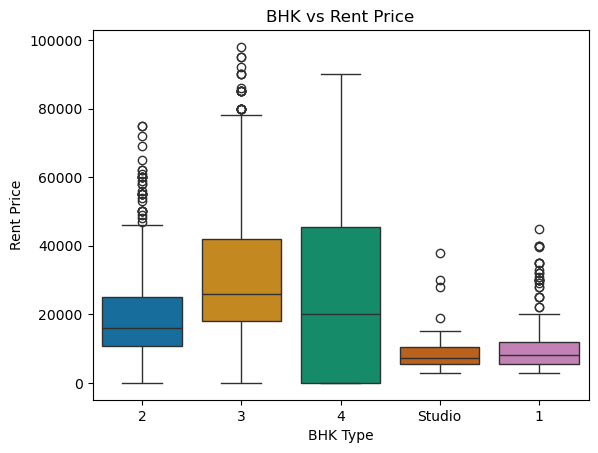

In [75]:
sns.boxplot(x="type_of_appartment(bhk)", y="price", data=data, palette="colorblind")

plt.title("BHK vs Rent Price")

plt.xlabel("BHK Type")

plt.ylabel("Rent Price")

plt.show()

- This boxplot compares rental price distributions across different BHK types.
- Generally, higher BHK apartments tend to have higher rental prices.

### Average Price For each type of appartment


In [80]:
pivot_table = pd.pivot_table(
    data,
    values="price",
    index="type_of_appartment(bhk)",
    aggfunc="mean"
)

pivot_table

,price
type_of_appartment(bhk),
1,10886.497890
2,19712.863056
3,31822.234055
4,25393.372590
Studio,10371.428571
